# 05 - Hyperparameter Tuning

## Objective

The purpose of this notebook is to improve the performance of the baseline CatBoost model through systematic hyperparameter tuning.

Using the preprocessed training dataset, multiple CatBoost configurations were evaluated to identify a better-performing model. The tuned model was then trained using early stopping and evaluated on a validation dataset to determine whether tuning improved predictive performance.

## Tasks Performed

### 1. Load Preprocessed Data

- Loaded the cleaned training and testing datasets produced during preprocessing.
- Verified dataset structure and data types.

### 2. Define Features and Target

- Separated predictor variables (X) from the target variable (y).
- Prepared datasets for model development and tuning.

### 3. Create Training and Validation Sets

- Split the training dataset into training and validation subsets.
- Reserved the validation dataset for hyperparameter tuning and model evaluation.
- Kept the testing dataset untouched for final evaluation.

### 4. Identify Categorical Features

- Identified categorical columns required by CatBoost.
- Configured CatBoost to use native categorical feature handling without one-hot encoding.

### 5. Establish Baseline Metrics

- Recorded baseline model performance from Notebook 04.
- Established benchmark metrics for comparison with the tuned model.

### 6. Hyperparameter Tuning

- Performed hyperparameter optimization using RandomizedSearchCV.
- Evaluated parameter combinations using 3-fold cross-validation and ROC-AUC scoring.
- Explored the following CatBoost hyperparameters:

  - iterations
  - learning_rate
  - depth
  - l2_leaf_reg
  - bagging_temperature
  - random_strength
  - one_hot_max_size

- Identified the best-performing hyperparameter combination.

### 7. Train Tuned CatBoost Model

- Trained a CatBoost model using the optimal hyperparameters.
- Applied early stopping using the validation dataset.
- Automatically retained the best-performing iteration to reduce overfitting.

### 8. Evaluate Tuned Model

- Evaluated validation performance using:

  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - ROC-AUC Score

- Generated a confusion matrix.
- Produced a classification report for class-wise performance analysis.

### 9. Baseline vs Tuned Model Comparison

- Compared baseline and tuned model performance across all evaluation metrics.
- Quantified performance improvements achieved through hyperparameter tuning.

### 10. Save Tuned Model

- Saved the tuned CatBoost model as a reusable model artifact.
- Verified successful model persistence for future evaluation and inference tasks.

## Best Hyperparameters

The optimal CatBoost configuration identified during tuning was:

- iterations = 1000
- learning_rate = 0.05
- depth = 6
- l2_leaf_reg = 5
- bagging_temperature = 0
- random_strength = 1
- one_hot_max_size = 2

## Key Results

### Baseline Model Performance

- Accuracy: 87.51%
- Precision: 77.98%
- Recall: 67.09%
- F1-Score: 72.13%
- ROC-AUC Score: 93.28%

### Tuned Model Performance

- Accuracy: 87.68%
- Precision: 78.54%
- Recall: 67.22%
- F1-Score: 72.44%
- ROC-AUC Score: 93.32%

### Improvement Achieved

- Accuracy: +0.17%
- Precision: +0.56%
- Recall: +0.13%
- F1-Score: +0.31%
- ROC-AUC: +0.04%

The tuned CatBoost model achieved consistent improvements across all evaluation metrics, demonstrating the effectiveness of hyperparameter optimization and early stopping.

## Outcome

At the completion of this notebook, an optimized CatBoost model has been trained, validated, and saved as a reusable model artifact (`catboost_income_model.cbm`).

The tuned model will serve as the final candidate model for threshold optimization, final testing, error analysis, responsible AI evaluation, and deployment activities in the subsequent notebooks.

## Load Preprocessed Data

### Objective

The purpose of this section is to load the cleaned and preprocessed datasets prepared during the preprocessing stage.

These datasets have already undergone:

- Missing value handling
- Duplicate record removal
- Target variable encoding

The loaded datasets will be used for hyperparameter tuning and model optimization.


After this step:

- The preprocessed training dataset will be available for model development.
- The preprocessed testing dataset will remain reserved for final evaluation.
- The datasets will be ready for feature-target separation and train-validation splitting.

In [22]:
import pandas as pd
import numpy as np
adult_train = pd.read_csv('adult_train_clean.csv')
adult_test = pd.read_csv('adult_test_clean.csv')

In [23]:
print("Training Shape :", adult_train.shape)
print("Testing Shape  :", adult_test.shape)

Training Shape : (32537, 15)
Testing Shape  : (16276, 15)


In [24]:
adult_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [25]:
adult_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0


In [26]:
adult_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education_num   32537 non-null  int64 
 5   marital_status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital_gain    32537 non-null  int64 
 11  capital_loss    32537 non-null  int64 
 12  hours_per_week  32537 non-null  int64 
 13  native_country  32537 non-null  object
 14  income          32537 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [27]:
adult_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16276 entries, 0 to 16275
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16276 non-null  int64 
 1   workclass       16276 non-null  object
 2   fnlwgt          16276 non-null  int64 
 3   education       16276 non-null  object
 4   education_num   16276 non-null  int64 
 5   marital_status  16276 non-null  object
 6   occupation      16276 non-null  object
 7   relationship    16276 non-null  object
 8   race            16276 non-null  object
 9   sex             16276 non-null  object
 10  capital_gain    16276 non-null  int64 
 11  capital_loss    16276 non-null  int64 
 12  hours_per_week  16276 non-null  int64 
 13  native_country  16276 non-null  object
 14  income          16276 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 1.9+ MB


## Define Features and Target

### Objective

The purpose of this section is to separate the predictor variables (features) from the target variable (income).

The feature set will be used for model training and hyperparameter tuning, while the target variable will be used to evaluate predictive performance.

### Feature Set (X)

The feature set consists of all demographic, educational, occupational, and financial attributes available in the dataset.

### Target Variable (y)

The target variable is:

- income

where:

- 0 → Income ≤ $50K

- 1 → Income > $50K


After this step:

- X_train and X_test will contain all predictor features.
- y_train and y_test will contain the target variable.
- The datasets will be ready for train-validation splitting and hyperparameter tuning.

In [28]:
# Separate features and target
X_train = adult_train.drop('income', axis=1)
y_train = adult_train['income']
X_test = adult_test.drop('income', axis=1)
y_test = adult_test['income']

In [29]:
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (32537, 14)
y_train Shape: (32537,)
X_test Shape : (16276, 14)
y_test Shape : (16276,)


## Create Training and Validation Sets

### Objective

The purpose of this section is to split the training dataset into training and validation subsets.

The training subset will be used to train CatBoost models during hyperparameter tuning, while the validation subset will be used to evaluate model performance and compare different parameter combinations.

The testing dataset will remain untouched and will be reserved exclusively for final evaluation in a later notebook.

After this step:

- X_train_final and y_train_final will be used for model training.
- X_val and y_val will be used for validation.
- X_test and y_test will remain unseen until final model evaluation.
- The project will maintain a proper Train → Validation → Test workflow.

In [30]:
from sklearn.model_selection import train_test_split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [31]:
print("Training Set Shape   :", X_train_final.shape)
print("Validation Set Shape :", X_val.shape)
print("Test Set Shape       :", X_test.shape)

Training Set Shape   : (26029, 14)
Validation Set Shape : (6508, 14)
Test Set Shape       : (16276, 14)


## Identify Categorical Features

### Objective

The purpose of this section is to identify the categorical features present in the dataset and prepare them for CatBoost.

Unlike many machine learning algorithms, CatBoost can handle categorical variables directly without requiring one-hot encoding or label encoding. Therefore, the categorical feature list must be provided to the model during training.

After this step:

- All categorical columns will be identified.
- A list of categorical feature names will be created.
- The categorical feature list will be supplied to CatBoost during model training and tuning.

In [32]:
# Identify categorical columns
cat_features = X_train_final.select_dtypes(
    include=['object']
).columns.tolist()
print("Number of Categorical Features:", len(cat_features))
cat_features

Number of Categorical Features: 8


['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

## Establish Baseline Metrics

### Objective

The purpose of this section is to record the performance of the baseline CatBoost model developed in the previous notebook.

These baseline metrics will serve as a reference point for evaluating the effectiveness of hyperparameter tuning.

The tuned model will later be compared against the baseline model to determine whether tuning improves predictive performance.

### Baseline Model Configuration

The baseline CatBoost model was trained using:

- loss_function = Logloss
- eval_metric = AUC
- random_seed = 42
- Native categorical feature handling

After this step:

- Baseline performance metrics will be documented.
- A benchmark will be established for comparison with the tuned model.
- Improvements achieved through hyperparameter tuning can be quantified.

In [33]:
baseline_metrics = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Baseline Score': [
        0.8751,
        0.7798,
        0.6709,
        0.7213,
        0.9328
    ]
})
baseline_metrics

,Metric,Baseline Score
0,Accuracy,0.8751
1,Precision,0.7798
2,Recall,0.6709
3,F1 Score,0.7213
4,ROC-AUC,0.9328


In [34]:
baseline_metrics['Baseline Score'] = (
    baseline_metrics['Baseline Score'] * 100
).round(2)
baseline_metrics

,Metric,Baseline Score
0,Accuracy,87.51
1,Precision,77.98
2,Recall,67.09
3,F1 Score,72.13
4,ROC-AUC,93.28


## Hyperparameter Tuning

### Objective

The purpose of this section is to optimize the performance of the CatBoost classifier by identifying an effective combination of hyperparameters.

Hyperparameter tuning helps improve model generalization and predictive performance by exploring different model configurations using the training data and evaluating them through cross-validation.

### Tuned Parameters

The following CatBoost hyperparameters were included in the search space:

- iterations: 500, 1000, 2000
- learning_rate: 0.03, 0.05, 0.1
- depth: 4, 6, 8, 10
- l2_leaf_reg: 1, 3, 5, 10
- bagging_temperature: 0, 0.5, 1
- random_strength: 1, 5, 10
- one_hot_max_size: 2, 10

### Search Strategy

The complete search space contains a large number of possible parameter combinations. Performing an exhaustive Grid Search across all combinations would require substantial computational resources and execution time.

Therefore, RandomizedSearchCV was used to efficiently sample parameter combinations from the required search space while significantly reducing computational cost.

A total of 10 randomly selected parameter combinations were evaluated.

### Evaluation Strategy

Hyperparameter combinations were evaluated using:

- 3-Fold Cross Validation
- ROC-AUC as the optimization metric
- Fixed random seed for reproducibility

The testing dataset remained untouched and was not used during the tuning process.

### Best Hyperparameters Identified

The best-performing parameter combination obtained during the randomized search was:

- iterations = 1000
- learning_rate = 0.05
- depth = 6
- l2_leaf_reg = 5
- bagging_temperature = 0
- random_strength = 1
- one_hot_max_size = 2

### Early Stopping

After identifying the best hyperparameter combination, the final tuned CatBoost model will be trained using a validation dataset and early stopping.

Training will automatically stop if the validation AUC does not improve for 100 consecutive iterations. This helps prevent overfitting and improves model generalization.

After tuning:

- The optimal hyperparameter combination will be identified.
- A tuned CatBoost model will be trained.
- Early stopping will reduce unnecessary training and overfitting.
- Validation performance will be compared against the baseline model.

In [35]:
import sys
!{sys.executable} -m pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

In [36]:
# Base CatBoost Configuration
catboost_base = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

In [40]:
# Hyperparameter Tuning
param_grid = {
    'iterations': [500, 1000, 2000],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 10],
    'bagging_temperature': [0, 0.5, 1],
    'random_strength': [1, 5, 10],
    'one_hot_max_size': [2, 10]
}

In [41]:
# Randomizedsearch
random_search = RandomizedSearchCV(
    estimator=catboost_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [42]:
# Run Hyperparameter Search
random_search.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostClassifier(eval_metric='AUC', loss_function='Logloss', random_seed=42, verbose=0),
                   n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.5, 1],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [500, 1000, 2000],
                                        'l2_leaf_reg': [1, 3, 5, 10],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'one_hot_max_size': [2, 10],
                                        'random_strength': [1, 5, 10]},
                   random_state=42, scoring='roc_auc', verbose=2)

## Train Tuned CatBoost Model

### Objective

The purpose of this section is to train a CatBoost classifier using the optimal hyperparameter combination identified during the tuning process.

The tuned model will be trained on the training subset and evaluated on the validation subset using early stopping to improve generalization performance and reduce overfitting.

### Best Hyperparameters

The optimal hyperparameter combination identified during randomized search will be used to configure the final tuned model.

### Early Stopping

The model will monitor validation AUC during training and automatically stop if performance does not improve for 100 consecutive iterations.

This helps:

- Reduce overfitting
- Avoid unnecessary training
- Select the best-performing iteration automatically

After this step:

- A tuned CatBoost model will be trained.
- Early stopping will be applied.
- The best-performing model iteration will be retained.
- The model will be ready for validation evaluation.

In [47]:
best_params = random_search.best_params_
print("Best Parameters:")
print(best_params)

Best Parameters:
{'random_strength': 1, 'one_hot_max_size': 2, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 1000, 'depth': 6, 'bagging_temperature': 0}


In [49]:
# Create Tuned Model
tuned_model = CatBoostClassifier(
    **best_params,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

In [50]:
# Train with Early Stopping
tuned_model.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100,
    use_best_model=True
)

0:	test: 0.8762089	best: 0.8762089 (0)	total: 14.6ms	remaining: 14.6s
100:	test: 0.9252033	best: 0.9252033 (100)	total: 1.66s	remaining: 14.8s
200:	test: 0.9289904	best: 0.9289904 (200)	total: 3.15s	remaining: 12.5s
300:	test: 0.9320763	best: 0.9320763 (300)	total: 4.68s	remaining: 10.9s
400:	test: 0.9326081	best: 0.9326081 (400)	total: 6.22s	remaining: 9.29s
500:	test: 0.9328267	best: 0.9328317 (499)	total: 7.77s	remaining: 7.74s
600:	test: 0.9330592	best: 0.9330826 (593)	total: 9.26s	remaining: 6.15s
700:	test: 0.9331243	best: 0.9331891 (614)	total: 10.8s	remaining: 4.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9331890854
bestIteration = 614

Shrink model to first 615 iterations.


CatBoostClassifier(bagging_temperature=0, depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, loss_function='Logloss', one_hot_max_size=2, random_seed=42, random_strength=1, verbose=100)

In [51]:
print("Best Iteration:")
print(tuned_model.get_best_iteration())

Best Iteration:
614


In [52]:
print("Best Validation Scores:")
print(tuned_model.get_best_score())

Best Validation Scores:
{'learn': {'Logloss': 0.2482122292676012}, 'validation': {'Logloss': 0.2701059244988537, 'AUC': 0.9331890853507395}}


**Training Summary**

The tuned CatBoost model was trained using the optimal hyperparameter combination identified during randomized search.

Although the model was configured for 1000 boosting iterations, early stopping halted training after validation performance stopped improving.

The best validation performance was achieved at iteration 614, resulting in a validation ROC-AUC score of approximately 93.32%.

The model was automatically reduced to the best-performing iteration, helping prevent overfitting while retaining optimal predictive performance.

## Evaluate Tuned Model

### Objective

The purpose of this section is to evaluate the performance of the tuned CatBoost model on the validation dataset.

The tuned model will be assessed using multiple classification metrics to determine whether hyperparameter tuning improved predictive performance compared to the baseline model.

### Evaluation Metrics

The following metrics will be calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In addition, a confusion matrix and classification report will be generated to provide a detailed assessment of model performance.

After this step:

- The performance of the tuned model will be quantified.
- Results will be compared against the baseline model.
- The effectiveness of hyperparameter tuning will be assessed.

In [53]:
# Generate predictions
y_val_pred = tuned_model.predict(X_val)
y_val_proba = tuned_model.predict_proba(X_val)[:, 1]

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})
evaluation_results['Score'] = evaluation_results['Score'].round(4)
evaluation_results

,Metric,Score
0,Accuracy,0.8768
1,Precision,0.7854
2,Recall,0.6722
3,F1 Score,0.7244
4,ROC-AUC,0.9332


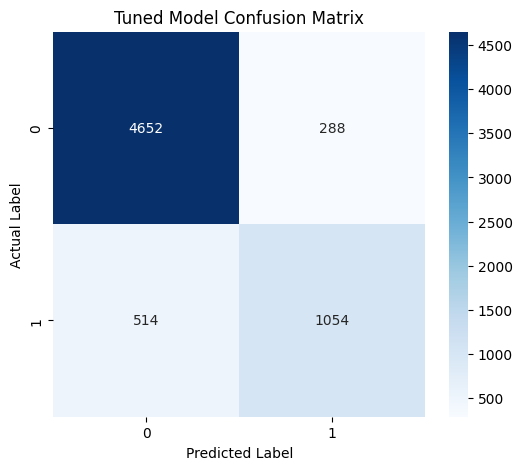

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Tuned Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [56]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_val,
        y_val_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4940
           1       0.79      0.67      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.84      0.81      0.82      6508
weighted avg       0.87      0.88      0.87      6508



**Evaluation Summary**

The tuned CatBoost model achieved an **accuracy of 87.68%**, indicating that the model correctly classified the majority of observations in the validation dataset.

The model obtained a **precision score of 78.54%**, meaning that when the model predicts an individual belongs to the high-income class (>50K), the prediction is correct approximately 79% of the time.

The **recall score of 67.22%** indicates that the model successfully identifies around 67% of all actual high-income individuals. This represents a slight improvement compared to the baseline model and demonstrates improved detection of high-income observations.

The **F1-score of 72.44%** reflects a balanced trade-off between precision and recall and shows a modest improvement over the baseline model.

The model achieved a **ROC-AUC score of 93.32%**, demonstrating excellent discrimination between individuals earning less than or equal to $50K and those earning more than $50K.

The confusion matrix revealed that the model correctly classified:

- 4,652 low-income individuals (True Negatives)
- 1,054 high-income individuals (True Positives)

while producing:

- 288 False Positives
- 514 False Negatives

Compared to the baseline model, the tuned CatBoost classifier achieved small but consistent improvements in accuracy, precision, recall, F1-score, and ROC-AUC. These results indicate that hyperparameter tuning and early stopping helped improve overall model performance while maintaining strong generalization capability.

## Baseline vs Tuned Model Comparison

### Objective

The purpose of this section is to compare the performance of the baseline CatBoost model with the tuned CatBoost model.

This comparison helps quantify the impact of hyperparameter tuning and determines whether the tuning process resulted in measurable performance improvements.

### Evaluation Metrics

The following metrics will be compared:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

After this step:

- The performance difference between the baseline and tuned models will be clearly documented.
- Improvements achieved through hyperparameter tuning will be quantified.
- The final model selection decision will be supported by objective performance metrics.

In [60]:
comparison_df.style.format({
    'Baseline': '{:.4f}',
    'Tuned': '{:.4f}',
    'Improvement': '{:+.4f}'
})

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.8751,0.8768,+0.0017
1,Precision,0.7798,0.7854,+0.0056
2,Recall,0.6709,0.6722,+0.0013
3,F1 Score,0.7213,0.7244,+0.0031
4,ROC-AUC,0.9328,0.9332,+0.0004


**Comparison Summary**

The tuned CatBoost model outperformed the baseline model across all evaluation metrics.

The largest improvement was observed in precision, indicating that the tuned model made more accurate high-income predictions while maintaining a similar recall level.

Small improvements were also observed in accuracy, F1-score, and ROC-AUC, demonstrating that hyperparameter tuning and early stopping contributed to better overall model performance.

Although the performance gains are modest, they are consistent across all evaluation metrics, suggesting that the tuned model generalizes slightly better than the baseline model.

Based on the validation results, the tuned CatBoost model is selected as the final candidate model for subsequent evaluation, threshold optimization, fairness analysis, and deployment tasks.

## Save Tuned Model

### Objective

The purpose of this section is to save the tuned CatBoost model as a reusable model artifact.

Saving the model allows it to be loaded later for inference, threshold optimization, fairness evaluation, and deployment without requiring retraining.

After this step:

- The tuned CatBoost model will be stored as a model artifact.
- The model can be reloaded for future predictions.
- The saved model will be used in subsequent project notebooks and the inference script.

In [61]:
# Save tuned model
tuned_model.save_model(
    "catboost_income_model.cbm"
)

In [62]:
import os
print(
    "Model Exists:",
    os.path.exists("catboost_income_model.cbm")
)

Model Exists: True
